In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import raster_vector as rv
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

# Fetching dataset

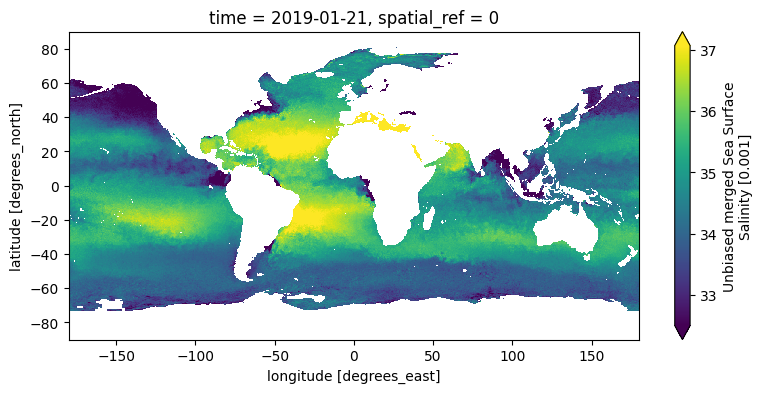

In [3]:
# use the fsspec filecache to cache the remote file locally (about 5 MB)
url = "filecache::https://dap.ceda.ac.uk/neodc/esacci/sea_surface_salinity/data/v05.5/GLOBALv5.5/7days/2019/ESACCI-SEASURFACESALINITY-L4-SSS-GLOBAL-MERGED_OI_7DAY_RUNNINGMEAN_DAILY_0.25deg-20190121-fv5.5.nc"

ds = xr.open_dataset(url).rio.write_crs('EPSG:4326')
da = ds.sss.isel(time=0)
da.plot.imshow(aspect=2.3, size=4, robust=True)

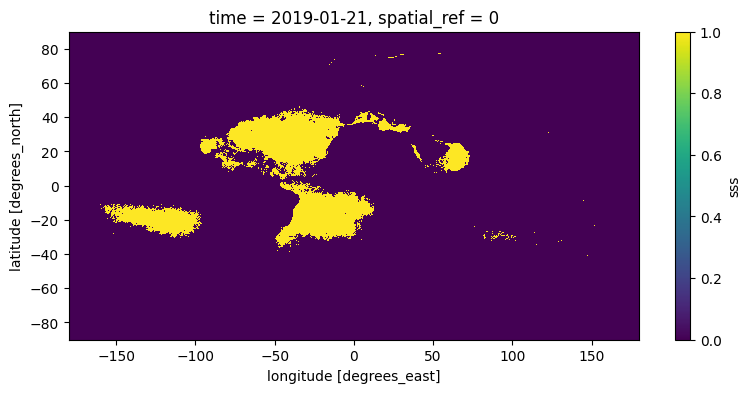

In [4]:
mask = da > 36
mask.plot.imshow(aspect=2.3, size=4)

# Boolean mask to polygons

Separate patches each become a Polygon in a GeoDataFrame. These are randomly sorted.  
The nice thing is that we can do some analysis using GeoPandas on the resulting polygons.

In [5]:
from pyproj import Geod

# Define the WGS84 ellipsoid model
geod = Geod(ellps="WGS84")

# Function to calculate area using pyproj's geodesic method
def calculate_geodesic_area(polygon):
    # Extract coordinates (lon, lat)
    lons, lats = zip(*list(polygon.exterior.coords))
    area, perim = geod.polygon_area_perimeter(lons, lats)
    # Area can be negative depending on winding order; return absolute value
    return abs(area)

In [6]:
df = mask.rv.to_polygons()

# compute area of each polygon and sort by area
df['area_sq_m'] = df.geometry.apply(calculate_geodesic_area)
df['area_sq_km'] = df['area_sq_m'] / 10**6

df = df.sort_values('area_sq_km', ascending=False).reset_index(drop=True)

# select the largest 9 polygons
df = df.nlargest(9, 'area_sq_km')

Text(999.3109097600267, 0.5, 'Polygon Area (km²)')

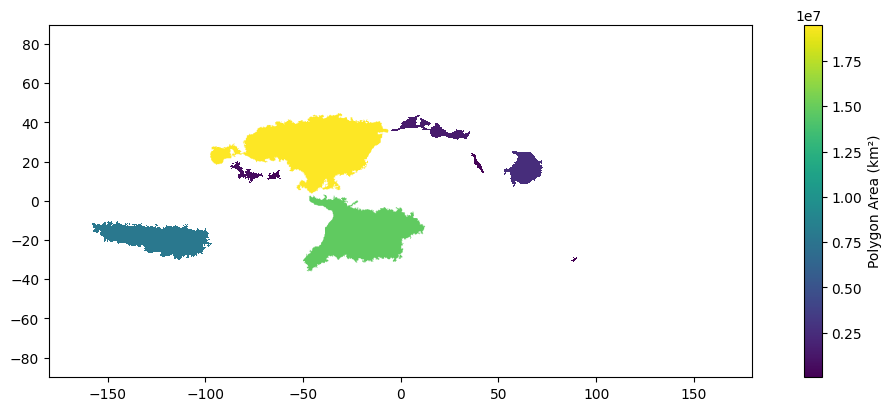

In [7]:
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

ax = df.plot(ax=ax, column='area_sq_km', cmap='viridis', legend=True)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

cbar = fig.get_children()[-1]
cbar.axes.set_ylabel('Polygon Area (km²)')

# Polygons to rasters

There are three different options for converting polygons to rasters using the `to_raster` method.
1.  A single polygon (even if MultiPolygon) -> a boolean raster 
2.  Multiple polygons -> an integer raster with unique IDs based on index
3.  Multiple polygons with a categorical column name -> an integer raster with category values

#### 1. Single polygon –> raster

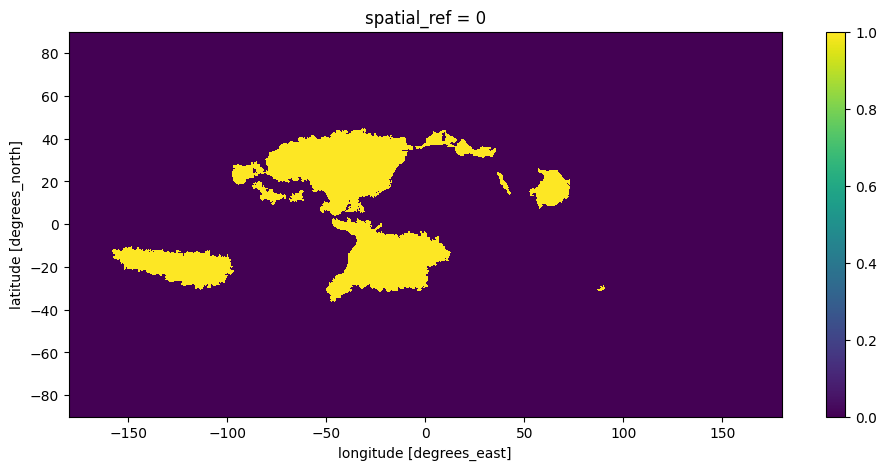

In [8]:
# 1. dissolve polygons to single geometry, then convert back to raster - results in boolean mask
bool_mask_out = df.dissolve().rv.to_raster(da)

# plotting
bool_mask_out.plot.imshow(aspect=2.3, size=5)

#### 2. Multiple polygons –> an integer raster

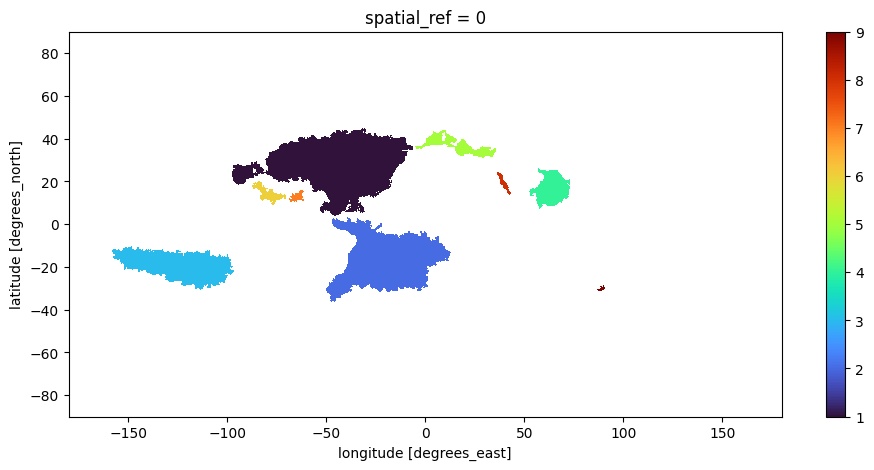

In [9]:
# 2. index set to polygon value - returns integer raster
int_mask_out = df.rv.to_raster(da)

# plotting
int_mask_out_masked = int_mask_out.where(int_mask_out != 0)
int_mask_out_masked.plot.imshow(aspect=2.3, size=5, cmap='turbo')

#### 3. Category column –> raster 

In [10]:
# 3. category column set to size based on area

# making size categories
big = df.area_sq_km > 5e6
small = df.area_sq_km <= 1e6
medium = ~(big | small)
df['size'] = ""
df.loc[big, 'size'] = "big"
df.loc[medium, 'size'] = "medium"
df.loc[small, 'size'] = "small"

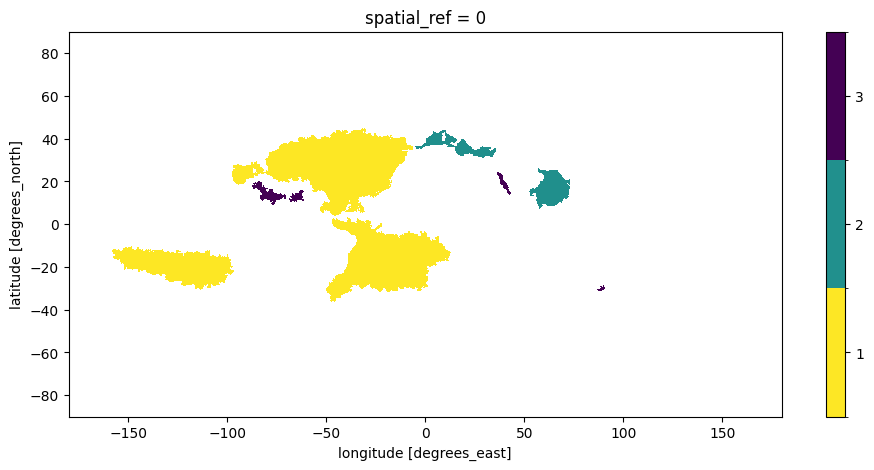

In [11]:
da_categories = df.rv.to_raster(da, by_column='size')

# plotting
img = da_categories.where(lambda x: x != 0).plot.imshow(aspect=2.3, size=5, levels=[0.5, 1.5, 2.5, 3.5], cmap='viridis_r')
img.colorbar.set_ticks([1, 2, 3])

# Numbered raster to polygons

(-90.0, 90.0)

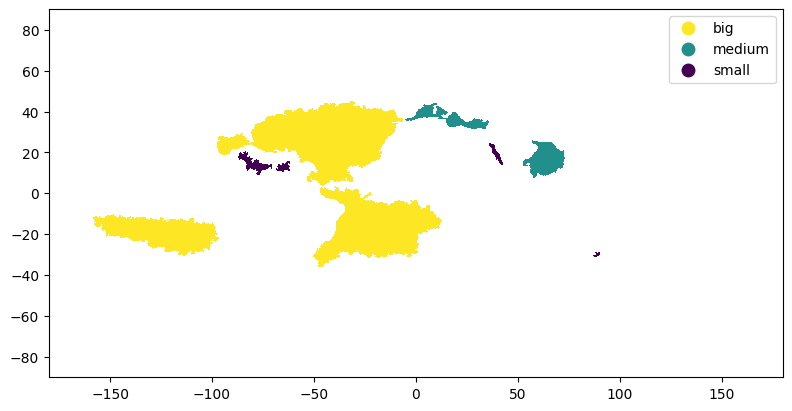

In [12]:
numbered_polygons = da_categories.rv.to_polygons(names=['background', 'big', 'medium', 'small'])

# plotting
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
numbered_polygons_wo_background = numbered_polygons.iloc[1:]
numbered_polygons_wo_background.plot(column='category', cmap='viridis_r', legend=True, ax=ax)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)